# Tutorial: fitting a gold-nanoparticle SAXS curve with PyTorch + automatic differentiation

Gold nanoparticles are well described by a simple analytical model: a homogeneous sphere, polydisperse in radius. This notebook walks through that model end-to-end on a real experimental SAXS curve -- using PyTorch and automatic differentiation, the same way the production fitting scripts in this repository work.

We will:

1. Load and plot the experimental gold-particle SAXS curve.
2. Define the sphere form factor and the polydisperse average **as differentiable PyTorch operations**.
3. Normalise both data and model using the Porod invariant -- the same convention used everywhere in this framework.
4. **Inspect the gradient of the loss with respect to the physical parameters** explicitly.
5. Fit three parameters (mean radius $m_R$, radius standard deviation $s_R$, residual background $b$) using `torch.optim.Adam`.
6. **Batched multi-start**: run 20 independent fits as a single tensor operation, the way the framework's production scripts do.

For production-scale fitting on the same model (hundreds of restarts, robust ensemble retention), see `fit_analytical_sphere.py` from the repository root.

**Next:** [`tutorial_simulation_model.ipynb`](tutorial_simulation_model.ipynb) introduces the stochastic interior model used for LNPs.

In [10]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.special import roots_legendre

device = torch.device("cpu")
dtype  = torch.float64   # plenty of headroom for the Porod integral

## 1. The data

Buffer-subtracted SAXS from gold nanoparticles measured at the CoSAXS beamline (MAX IV). Three columns: `q` ($\AA^{-1}$), `I(q)`, `sigma_I`.

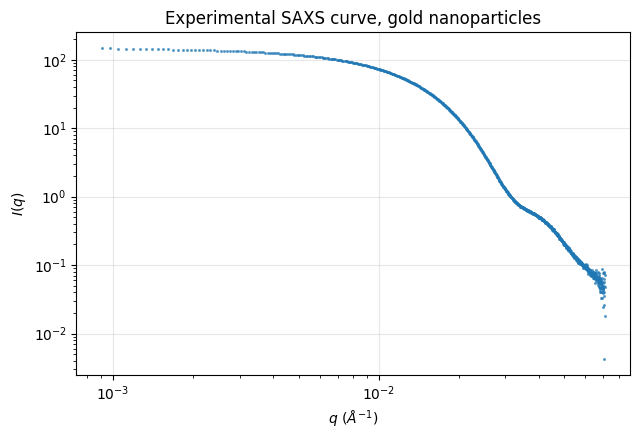

In [11]:
df = pd.read_csv("../data/gold_particles/Au_86116.csv")
q_all = df["q"].to_numpy()
I_all = df["I"].to_numpy()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(q_all, I_all, ".", markersize=2.5, alpha=0.6, color="tab:blue")
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.set_title("Experimental SAXS curve, gold nanoparticles")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. The sphere model in PyTorch

For a uniform sphere of radius $R$:

$$I(q, R) \;=\; R^{6}\,\bigl[\,f(qR)\bigr]^{2}, \qquad f(x) \;=\; \frac{3\bigl(\sin x - x \cos x\bigr)}{x^{3}},\quad f(0) = 1.$$

Real samples have a distribution of radii, so we average over it:

$$\bar I(q;\, m_R, s_R) \;=\; \int p(R \,;\, m_R, s_R)\,I(q, R)\,\mathrm d R,$$

with $p(R)$ a truncated log-normal of mean $m_R$ and standard deviation $s_R$. The integral is evaluated with Gauss-Legendre quadrature. Polydispersity *smooths* the sharp monodisperse minima.

Everything below is written in PyTorch — every operation is differentiable with respect to the physical parameters $(m_R, s_R)$. The Gauss-Legendre nodes and weights themselves are *not* differentiable; they are constants we precompute and store as fixed tensors.

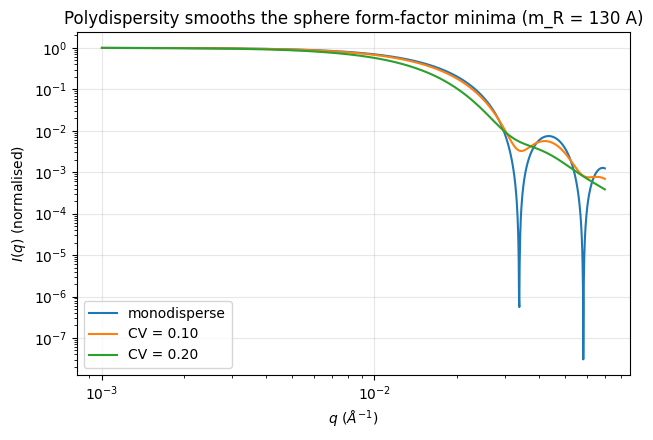

In [12]:
R_LO, R_HI = 10.0, 1000.0
N_QUAD = 64

# Quadrature nodes/weights -- constants, no autograd through these
_nodes_np, _weights_np = roots_legendre(N_QUAD)
_nodes   = torch.tensor(_nodes_np,   dtype=dtype, device=device)
_weights = torch.tensor(_weights_np, dtype=dtype, device=device)
R_quad   = 0.5 * (R_HI - R_LO) * _nodes + 0.5 * (R_HI + R_LO)   # (n_quad,)
jac      = 0.5 * (R_HI - R_LO)

def f_sphere(x):
    """Normalised sphere amplitude, Taylor expansion near 0 to avoid 0/0."""
    small = torch.abs(x) < 1e-3
    safe  = torch.where(small, torch.ones_like(x), x)
    return torch.where(
        small,
        1.0 - x**2 / 10.0 + x**4 / 280.0,
        3.0 * (torch.sin(x) - x * torch.cos(x)) / safe**3,
    )

def trunc_lognormal_pdf_on_quad(m, s):
    """PDF evaluated on the fixed R_quad nodes, normalised so the Gauss-Legendre quadrature integrates to 1.
    Broadcasts: m, s of shape (...,) -> output of shape (..., n_quad)."""
    m = m.unsqueeze(-1)
    s = s.unsqueeze(-1)
    sigma_ln = torch.sqrt(torch.log(1.0 + (s / m)**2))
    mu_ln    = torch.log(m) - 0.5 * sigma_ln**2
    log_R    = torch.log(R_quad)
    pdf = (torch.exp(-0.5 * ((log_R - mu_ln) / sigma_ln)**2)
           / (R_quad * sigma_ln * np.sqrt(2.0 * np.pi)))
    norm = (pdf * _weights * jac).sum(-1, keepdim=True)
    return pdf / norm

def I_sphere_poly(q, m_R, s_R):
    """Polydisperse sphere intensity.
    q: (n_q,);  m_R, s_R: scalar tensor or shape (N,).
    Returns: same leading dims as m_R, with last dim = n_q."""
    pdf = trunc_lognormal_pdf_on_quad(m_R, s_R)               # (..., n_quad)
    qR  = q.unsqueeze(-1) * R_quad.unsqueeze(0)               # (n_q, n_quad)
    I_mono = (R_quad.unsqueeze(0)**3 * f_sphere(qR))**2        # (n_q, n_quad)
    return (pdf * _weights * jac) @ I_mono.t()                # (..., n_q)

# Quick sanity check: plot the model at three polydispersity levels
q_plot = torch.linspace(1e-3, 0.07, 800, dtype=dtype)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for cv in [0.001, 0.10, 0.20]:
    m_R_t = torch.tensor(130.0, dtype=dtype)
    s_R_t = torch.tensor(max(cv * 130.0, 1e-3), dtype=dtype)
    I = I_sphere_poly(q_plot, m_R_t, s_R_t).detach().numpy()
    label = "monodisperse" if cv < 0.01 else f"CV = {cv:.2f}"
    ax.loglog(q_plot.numpy(), I / I.max(), label=label)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$ (normalised)")
ax.set_title("Polydispersity smooths the sphere form-factor minima (m_R = 130 A)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Porod-invariant normalisation

SAXS intensities depend on concentration, beam intensity, sample thickness, and other things we don't want to fit. To compare *shapes* without carrying a free scale parameter, we divide both data and model by the **Porod invariant**

$$Q_w \;=\; \int q^{2}\,I(q)\,\mathrm d q.$$

The normalised intensity

$$I_{\mathrm{PI}}(q) \;=\; \frac{I(q)}{Q_w}$$

is dimensionless. This is the convention used everywhere in this framework (see `fit_experimental_curve.py` and the loss definition in the paper).

After buffer subtraction the data still carries a small constant background $b$. We will fit it as a third free parameter.

In [14]:
def porod_normalize(q, I):
    """I / int q^2 I dq, trapezoidal rule on the last axis."""
    integrand = q**2 * I
    dq = q[1:] - q[:-1]
    avg = 0.5 * (integrand[..., :-1] + integrand[..., 1:])
    Qw = (avg * dq).sum(-1, keepdim=True)
    return I / Qw

# Choose the fit window: drop very low q (potential parasitic scattering)
# and very high q (noise floor).
Q_MIN, Q_MAX = 0.002, 0.06
mask = (q_all >= Q_MIN) & (q_all <= Q_MAX) & (I_all > 0)
q_fit = torch.tensor(q_all[mask], dtype=dtype, device=device)
I_fit = torch.tensor(I_all[mask], dtype=dtype, device=device)
print(f"Fit window: q in [{Q_MIN}, {Q_MAX}] A^-1, {q_fit.shape[0]} points")

Fit window: q in [0.002, 0.06] A^-1, 816 points


## 4. The loss, and one explicit gradient call

Three free parameters, all log-parameterised so they stay positive automatically (the optimiser sees $\log m_R$, $\log s_R$, $\log b$ as unbounded real numbers, and we exponentiate inside the loss).

The loss is RMSE in $\log_{10}$ of the Porod-normalised intensity, exactly the same convention as the LNP fitting in the rest of the framework.

Before fitting, let's look at the gradient of the loss with respect to the physical parameters at our initial guess. **This is what automatic differentiation lets us do**: it tells us not just the loss value, but exactly which way each parameter should move to decrease it. The optimiser will then take that gradient information and follow it.

In [15]:
def loss_fn(log_params, q, I_data):
    """log_params: (..., 3) for (log m_R, log s_R, log b).  Returns (...,) loss."""
    m_R = torch.exp(log_params[..., 0])
    s_R = torch.exp(log_params[..., 1])
    b   = torch.exp(log_params[..., 2])
    I_clean = I_data - b.unsqueeze(-1)
    I_model = I_sphere_poly(q, m_R, s_R)
    eps = 1e-30
    I_data_PI  = porod_normalize(q, torch.clamp(I_clean, min=eps))
    I_model_PI = porod_normalize(q, torch.clamp(I_model, min=eps))
    rmse = torch.sqrt(((torch.log10(I_model_PI) - torch.log10(I_data_PI))**2).mean(-1))
    # Soft penalty if b is large enough to make data go negative anywhere
    invalid = (I_clean <= 0).any(-1)
    return torch.where(invalid, rmse + 100.0, rmse)

log_params0 = torch.tensor(
    [np.log(200.0), np.log(30.0), np.log(0.04)],
    requires_grad=True, dtype=dtype, device=device,
)
loss0 = loss_fn(log_params0, q_fit, I_fit)
grads = torch.autograd.grad(loss0, log_params0)[0]

print(f"Initial guess:  m_R = 200 A, s_R = 30 A, b = 0.04")
print(f"loss at initial guess      = {loss0.item():.4f}")
print(f"d(loss) / d(log m_R)       = {grads[0].item():+.4e}")
print(f"d(loss) / d(log s_R)       = {grads[1].item():+.4e}")
print(f"d(loss) / d(log b)         = {grads[2].item():+.4e}")
print("\nPositive gradient on log m_R means 'increasing m_R increases the loss',")
print("so the optimiser will decrease m_R from the initial 200 A.")

Initial guess:  m_R = 200 A, s_R = 30 A, b = 0.04
loss at initial guess      = 0.2760
d(loss) / d(log m_R)       = +5.1104e-01
d(loss) / d(log s_R)       = -3.9980e-02
d(loss) / d(log b)         = -9.7283e-03

Positive gradient on log m_R means 'increasing m_R increases the loss',
so the optimiser will decrease m_R from the initial 200 A.


## 5. Single fit with Adam

`torch.optim.Adam` takes the parameter tensor, takes the gradient, and applies an adaptive update -- per-parameter step sizes that scale with the gradient history. We run for 2000 steps with a constant learning rate of $10^{-2}$ (matches the framework's production hyperparameters).

Fit results (RMSE_log = 0.0205):
  m_R = 130.46 A
  s_R = 26.55 A   (CV = 0.204)
  b   = 0.0058


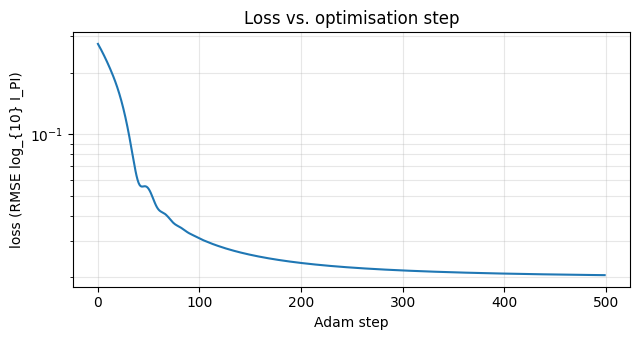

In [17]:
torch.manual_seed(0)
log_params = torch.tensor(
    [np.log(200.0), np.log(30.0), np.log(0.04)],
    requires_grad=True, dtype=dtype, device=device,
)
optimizer = torch.optim.Adam([log_params], lr=1e-2)

loss_history = []
for step in range(500):
    optimizer.zero_grad()
    loss = loss_fn(log_params, q_fit, I_fit)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

m_R_fit = torch.exp(log_params[0]).item()
s_R_fit = torch.exp(log_params[1]).item()
b_fit   = torch.exp(log_params[2]).item()
print(f"Fit results (RMSE_log = {loss_history[-1]:.4f}):")
print(f"  m_R = {m_R_fit:.2f} A")
print(f"  s_R = {s_R_fit:.2f} A   (CV = {s_R_fit/m_R_fit:.3f})")
print(f"  b   = {b_fit:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.semilogy(loss_history, color="tab:blue")
ax.set_xlabel("Adam step")
ax.set_ylabel("loss (RMSE log_{10} I_PI)")
ax.set_title("Loss vs. optimisation step")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3475628/1774822560.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


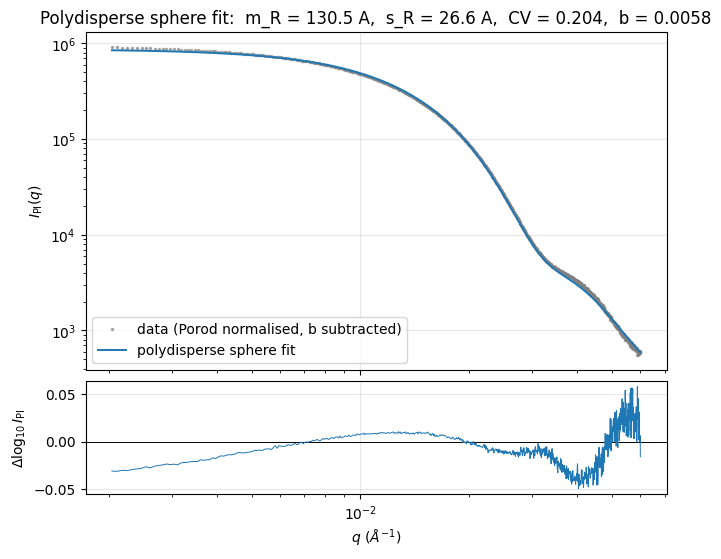

In [18]:
# Fit overlay + residual
with torch.no_grad():
    m_R_t = torch.tensor(m_R_fit, dtype=dtype)
    s_R_t = torch.tensor(s_R_fit, dtype=dtype)
    I_clean_t  = I_fit - b_fit
    I_data_PI  = porod_normalize(q_fit, I_clean_t).numpy()
    I_model_PI = porod_normalize(q_fit, I_sphere_poly(q_fit, m_R_t, s_R_t)).numpy()
q_np = q_fit.numpy()
residual = np.log10(I_model_PI) - np.log10(I_data_PI)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7.5, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)
ax1.loglog(q_np, I_data_PI, ".", color="0.5", markersize=3, alpha=0.6, label="data (Porod normalised, b subtracted)")
ax1.loglog(q_np, I_model_PI, color="tab:blue", linewidth=1.4, label="polydisperse sphere fit")
ax1.set_ylabel(r"$I_{\mathrm{PI}}(q)$")
ax1.set_title(f"Polydisperse sphere fit:  m_R = {m_R_fit:.1f} A,  s_R = {s_R_fit:.1f} A,  CV = {s_R_fit/m_R_fit:.3f},  b = {b_fit:.4f}")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.axhline(0, color="k", linewidth=0.7)
ax2.plot(q_np, residual, color="tab:blue", linewidth=0.7)
ax2.set_xscale("log")
ax2.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax2.set_ylabel(r"$\Delta\log_{10} I_{\mathrm{PI}}$")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Batched multi-start: 20 fits as one tensor operation

Adam is not the fastest optimiser for a smooth three-parameter problem on its own, a quasi-Newton method like L-BFGS would converge in fewer iterations. The framework still uses Adam because **it batches trivially**: each restart becomes a row of a `(N_restarts, N_params)` tensor, and a single `optimizer.step()` updates all of them in parallel.

This is where automatic differentiation pays off. The backward pass through the polydispersity integral is exactly the same kernel for one restart or twenty thousand; only the tensor sizes change. The production fitting scripts (`fit_analytical_sphere.py`, `fit_experimental_curve.py`) use this same pattern with thousands of restarts on the GPU.

For a well-posed problem like polydisperse spheres on clean gold data, every random initial condition should converge to the same $(m_R, s_R, b)$, a single tight cluster in the scatter below. For lipid nanoparticles the same machinery produces **multiple distinct clusters**, which is the framework's identifiability story.

step 0000 | loss_sum=0.0204701 | loss_mean=12.0704 | lr=1.000e-02
step 0050 | loss_sum=0.0204701 | loss_mean=0.0984262 | lr=9.748e-03
step 0100 | loss_sum=0.0204701 | loss_mean=0.0490761 | lr=9.036e-03
step 0150 | loss_sum=0.0204701 | loss_mean=0.0397692 | lr=7.934e-03
step 0200 | loss_sum=0.0204701 | loss_mean=0.0354192 | lr=6.550e-03
step 0250 | loss_sum=0.0204701 | loss_mean=0.0329598 | lr=5.019e-03
step 0300 | loss_sum=0.0204701 | loss_mean=0.0315035 | lr=3.491e-03
step 0350 | loss_sum=0.0204701 | loss_mean=0.0306574 | lr=2.115e-03
step 0400 | loss_sum=0.0204701 | loss_mean=0.0302103 | lr=1.027e-03
step 0450 | loss_sum=0.0204701 | loss_mean=0.0300219 | lr=3.328e-04
step 0499 | loss_sum=0.0204701 | loss_mean=0.0299688 | lr=1.000e-04
Best loss = 0.0199
Retained 58/200 restarts (within 5% of best).
Retained m_R: mean = 130.50 A,  std = 0.2004
Retained s_R: mean = 26.55 A,  std = 0.0162
Retained b  : mean = 0.0061,  std = 0.0019


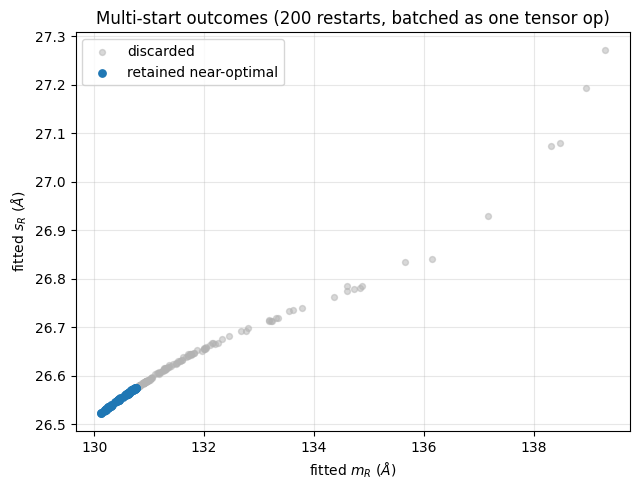

In [32]:
torch.manual_seed(0)
N = 200
log_m0 = torch.log(torch.empty(N, dtype=dtype).uniform_( 80.0, 300.0))
log_s0 = torch.log(torch.empty(N, dtype=dtype).uniform_( 10.0,  60.0))
log_b0 = torch.log(torch.empty(N, dtype=dtype).uniform_(0.005,   0.1))
log_batch = torch.stack([log_m0, log_s0, log_b0], dim=-1).to(device).clone().requires_grad_(True)

optimizer = torch.optim.Adam([log_batch], lr=1e-2)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=500,
    eta_min=1e-4,
)

for step in range(500):
    optimizer.zero_grad()

    losses_b = loss_fn(log_batch, q_fit, I_fit)   # shape (N,)
    losses_b.sum().backward()

    optimizer.step()
    scheduler.step()

    # optional
    if step % 50 == 0 or step == 499:
        print(
            f"step {step:04d} | "
            f"loss_sum={loss.item():.6g} | "
            f"loss_mean={losses_b.mean().item():.6g} | "
            f"lr={scheduler.get_last_lr()[0]:.3e}"
        )

with torch.no_grad():
    losses_final = loss_fn(log_batch, q_fit, I_fit)
    mR = torch.exp(log_batch[:, 0])
    sR = torch.exp(log_batch[:, 1])
    bv = torch.exp(log_batch[:, 2])
    best = losses_final.min().item()
    keep = losses_final <= 1.1 * best

print(f"Best loss = {best:.4f}")
print(f"Retained {int(keep.sum().item())}/{N} restarts (within 5% of best).")
print(f"Retained m_R: mean = {mR[keep].mean().item():.2f} A,  std = {mR[keep].std().item():.4f}")
print(f"Retained s_R: mean = {sR[keep].mean().item():.2f} A,  std = {sR[keep].std().item():.4f}")
print(f"Retained b  : mean = {bv[keep].mean().item():.4f},  std = {bv[keep].std().item():.4f}")

mR_np = mR.numpy(); sR_np = sR.numpy(); keep_np = keep.numpy()
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(mR_np[~keep_np], sR_np[~keep_np], s=18, color="0.7", alpha=0.5, label="discarded")
ax.scatter(mR_np[ keep_np], sR_np[ keep_np], s=28, color="tab:blue", label="retained near-optimal")
ax.set_xlabel(r"fitted $m_R$ ($\AA$)")
ax.set_ylabel(r"fitted $s_R$ ($\AA$)")
ax.set_title(f"Multi-start outcomes ({N} restarts, batched as one tensor op)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. The fitted radius distribution

Translating the best-fit $(m_R, s_R)$ back into a physical radius PDF.

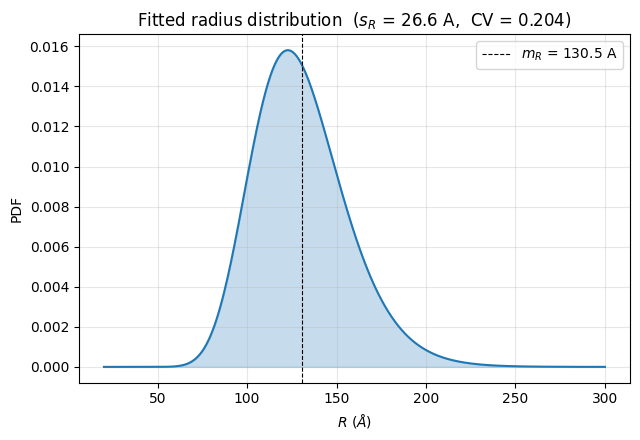

In [30]:
with torch.no_grad():
    R_grid_t = torch.linspace(20.0, 300.0, 600, dtype=dtype)
    # Re-use the same pdf computation but evaluated on R_grid_t rather than R_quad
    sigma_ln = np.sqrt(np.log(1.0 + (s_R_fit / m_R_fit)**2))
    mu_ln    = np.log(m_R_fit) - 0.5 * sigma_ln**2
    R_np = R_grid_t.numpy()
    pdf_R = np.exp(-0.5 * ((np.log(R_np) - mu_ln) / sigma_ln)**2) / (R_np * sigma_ln * np.sqrt(2 * np.pi))
    pdf_R /= np.trapezoid(pdf_R, R_np)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.fill_between(R_np, pdf_R, color="tab:blue", alpha=0.25)
ax.plot(R_np, pdf_R, color="tab:blue")
ax.axvline(m_R_fit, color="k", linestyle="--", linewidth=0.8, label=f"$m_R$ = {m_R_fit:.1f} A")
ax.set_xlabel(r"$R$ ($\AA$)")
ax.set_ylabel("PDF")
ax.set_title(f"Fitted radius distribution  ($s_R$ = {s_R_fit:.1f} A,  CV = {s_R_fit/m_R_fit:.3f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary and bridge to the LNP framework

We fit a real experimental SAXS curve with a three-parameter analytical model using PyTorch and automatic differentiation. The fit converged from a single trivial initial guess in 500 Adam steps, and 200 random restarts, run as a single batched tensor operation, agree to sub-angstrom precision on all three parameters. The answer is unique.

**This is the easy case.** Polydisperse spheres on clean gold data are a *well-posed* SAXS inverse problem: one SAXS curve constrains $(m_R, s_R)$ uniquely.

For lipid nanoparticles, the framework's main contribution is exposing that the same problem *stops being well-posed* once the particle interior is heterogeneous: distinct combinations of size-distribution and interior-structure parameters can produce SAXS curves that are indistinguishable within experimental noise. The same batched-Adam machinery applied to LNP fitting then returns multiple distinct clusters of solutions, rather than the single tight cluster we see here, and that cluster structure is the readout of which structural questions the data can and cannot answer. See `fit_experimental_curve.py` and the identifiability discussion in the [project README](../README.md).

### A note on the choice of distribution

We assumed a truncated log-normal radius distribution. Other choices (Schultz, gamma, truncated Gaussian, or even non-parametric distributions) would slot in with the same machinery, only the PDF function changes; the polydispersity integration, the Porod normalisation, the loss, and the Adam optimiser are unchanged. For a unimodal sample with moderate polydispersity, the SAXS data typically does not distinguish between these shape choices, so log-normal is a convenient default. For deliberately multi-modal populations (for example, samples that contain a fraction of aggregates), a mixture-of-log-normals or similar model would be the right move, at the cost of more parameters and a more delicate identifiability story.

### Production-scale fitting

For production-scale fitting on the same polydisperse-sphere model (thousands of restarts on the GPU, robust ensemble retention), use the command-line script `fit_analytical_sphere.py` from the repository root.